In [1]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (20640, 9)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [8]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [9]:
target_column = "MedHouseVal"

In [10]:
X = df.drop(columns=[target_column])
y = df[target_column]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [14]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

RMSE: 0.7455813830127763
MAE: 0.533200130495656
R² Score: 0.5757877060324508


In [15]:
metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R² Score"],
    "Value": [rmse, mae, r2]
})

metrics_df

,Metric,Value
0,RMSE,0.745581
1,MAE,0.533200
2,R² Score,0.575788


In [16]:
residuals = y_test - y_pred

print(residuals.head())

20046   -0.242123
3024    -1.306017
15663    2.290351
20484   -0.652926
9814     0.175343
Name: MedHouseVal, dtype: float64


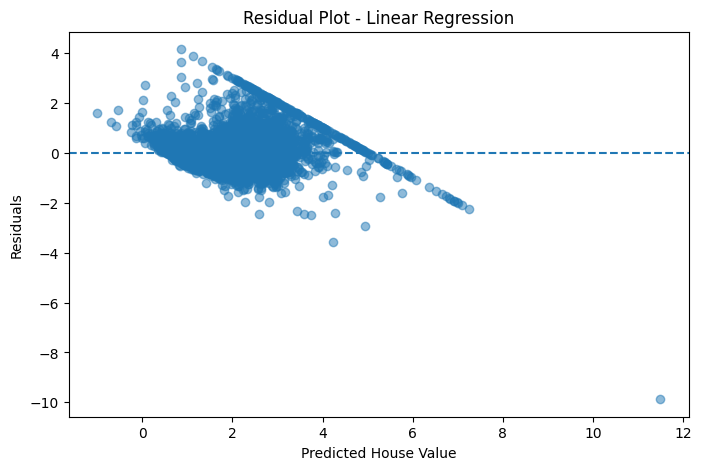

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Value")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")

plt.show()

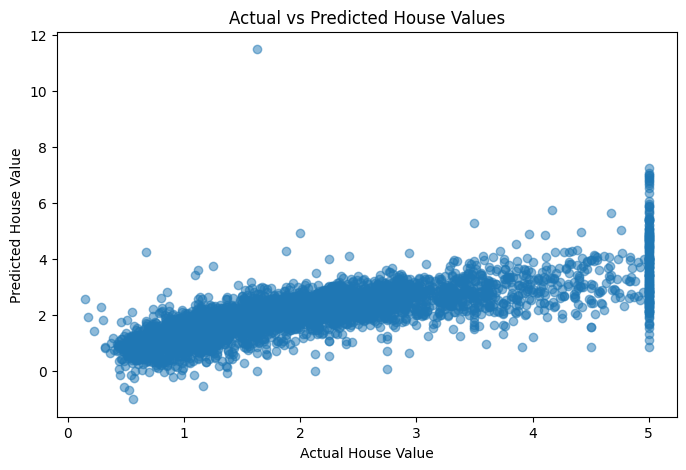

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

In [19]:

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison_df.head(10)

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [20]:
sample_predictions = comparison_df.head(10).copy()

sample_predictions["Error"] = (
    sample_predictions["Actual"] -
    sample_predictions["Predicted"]
)

sample_predictions

,Actual,Predicted,Error
0,0.47700,0.719123,-0.242123
1,0.45800,1.764017,-1.306017
2,5.00001,2.709659,2.290351
3,2.18600,2.838926,-0.652926
4,2.78000,2.604657,0.175343
5,1.58700,2.011754,-0.424754
6,1.98200,2.645500,-0.663500
7,1.57500,2.168755,-0.593755
8,3.40000,2.740746,0.659254
9,4.46600,3.915615,0.550385


In [21]:
joblib.dump(model, "house_price_linear_regression.pkl")

['house_price_linear_regression.pkl']

In [22]:
import os

print(os.path.exists("house_price_linear_regression.pkl"))

True


In [23]:
loaded_model = joblib.load("house_price_linear_regression.pkl")

In [24]:
loaded_predictions = loaded_model.predict(X_test)

print(loaded_predictions[:5])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


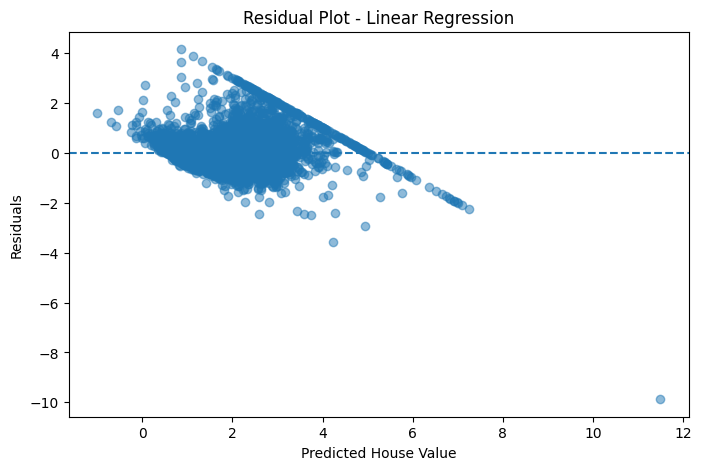

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Value")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")

plt.savefig("residual_plot.png", dpi=300, bbox_inches="tight")

plt.show()

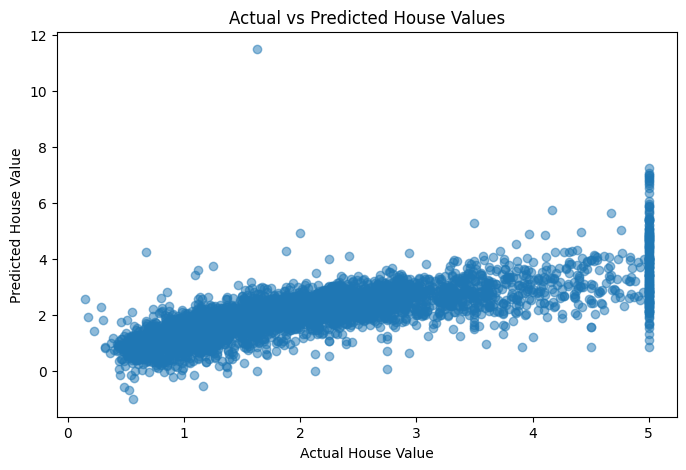

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

In [27]:
sample_predictions.to_csv(
    "sample_predictions.csv",
    index=False
)

In [28]:
metrics_df.to_csv(
    "evaluation_metrics.csv",
    index=False
)

## Conclusion

A Linear Regression model was trained to predict house values using
the California Housing Dataset.

The dataset was loaded using scikit-learn, checked for missing values,
and divided into training and testing sets.

The model was evaluated using RMSE, MAE, and R² score.
A residual plot and actual-versus-predicted visualization were also
created to analyze model performance.

The trained model was saved as a `.pkl` file so that it can be
loaded and used for future predictions.
